Potential Analyses

- Target variable over time
- Distributional analysis of subset(s) to overall sample
- Generative distribution (reconstruct "story" based on underlying statistical properties)


In [1]:
import polars as pl
import pandas as pd
import seaborn as sns
import numpy as np

## Routine Task Intensity


In [42]:
df_rti_industries = pd.read_parquet("../data/processed/routine_task_intensity/routine_task_intensity_industry.parquet")
df_rti_subsector = pd.read_parquet("../data/processed/routine_task_intensity/routine_task_intensity_subsector.parquet")


<Axes: xlabel='r_cog_industry', ylabel='Density'>

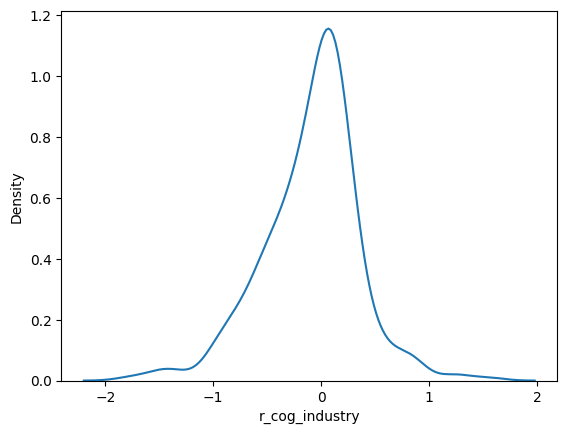

In [43]:
sns.kdeplot(df_rti_industries["r_cog_industry"])

<Axes: xlabel='r_man_subsector', ylabel='Count'>

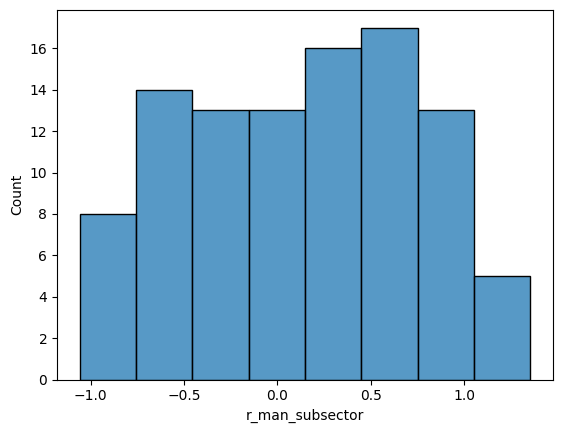

In [48]:
sns.histplot(df_rti_subsector["r_man_subsector"])

In [38]:
df_rti_industries.sample(5)

,industry_code,sector_code,subsector_code,industry_group_code,naics_industry_code,industry_title,sector_title,subsector_title,r_cog_industry,r_man_industry,offshor_industry
289,62220L,620000,622000,622200,622200,Psychiatric and substance abuse hospitals; local,Healthcare and social assistance,"Hospitals; state, local, and private",0.050723,-1.044120,-0.247589
126,313000,310000,313000,313000,313000,Textile mills,Manufacturing,Textile mills and textile product mills,0.125822,0.687289,-0.028600
8,62220P,620000,622000,622200,622200,Psychiatric and substance abuse hospitals; pri...,Healthcare and social assistance,"Hospitals; state, local, and private",-0.055448,-0.785193,-0.107240
120,487200,480000,487000,487200,487200,"Scenic and sightseeing transportation, water",Transportation and warehousing,Scenic and sightseeing transportation,0.031054,0.224019,-0.278330
162,621600,620000,621000,621600,621600,Home healthcare services,Healthcare and social assistance,Ambulatory healthcare services,-0.087632,-0.590240,-0.534013


## Industries


In [18]:
df_industries = pd.read_parquet("../data/processed/industries/industries.parquet")
df_occupations = pd.read_parquet("../data/processed/occupations/occupations.parquet")

In [19]:
df_industries[["industry_code", "sector_code", "subsector_code", "industry_group_code", "naics_industry_code"]].nunique()

industry_code          292
sector_code             25
subsector_code          90
industry_group_code    241
naics_industry_code    263
dtype: int64

In [20]:
df_industry_occupations = df_industries.merge(df_occupations, on="occupation_code", how="left")

In [26]:
df_industries.columns

Index(['occupation_type', 'industry_type', 'industry_code', 'sector_code',
       'subsector_code', 'industry_group_code', 'naics_industry_code',
       'industry_title', 'occupation_code', '2023_percent_of_industry',
       '2033_percent_of_industry', 'sector_title', 'subsector_title'],
      dtype='object')

In [22]:
df_industry_occupations.sample(5)

,occupation_type,industry_type,industry_code,sector_code,subsector_code,industry_group_code,naics_industry_code,industry_title,occupation_code,2023_percent_of_industry,2033_percent_of_industry,sector_title,subsector_title,occupation_title,occupation_level,occupation_code_prefix
15711,Line item,Line item,482000,480000,482000,482000,482000,Rail transportation,534099,0.1,0.1,Transportation and warehousing,Rail transportation,"Rail Transportation Workers, All Other",detailed_occupation,53
8415,Line item,Line item,332720,330000,332000,332700,332720,"Turned product and screw, nut, and bolt manufa...",537062,2.1,2.2,Manufacturing,Fabricated metal product manufacturing,"Laborers and Freight, Stock, and Material Move...",detailed_occupation,53
754,Line item,Line item,111000,110000,111000,111000,111000,Crop production,537051,0.9,0.9,"Agriculture, forestry, fishing and hunting",Crop production,Industrial Truck and Tractor Operators,detailed_occupation,53
26779,Line item,Line item,61120S,610000,611000,611200,611200,Junior colleges; state,151241,0.0,0.0,"Educational services; state, local, and private","Educational services; state, local, and private",Computer Network Architects,detailed_occupation,15
31754,Line item,Line item,624300,620000,624000,624300,624300,Vocational rehabilitation services,319092,0.0,0.0,Healthcare and social assistance,Social assistance,Medical Assistants,detailed_occupation,31


In [24]:
temp_df = df_industry_occupations[df_industry_occupations.sector_code == "510000"][["sector_title", "industry_title", "occupation_title", "2023_percent_of_industry"]].sort_values(by="2023_percent_of_industry", ascending=False)
temp_df[temp_df["2023_percent_of_industry"] > 1]

,sector_title,industry_title,occupation_title,2023_percent_of_industry
17989,Information,Motion picture and video exhibition,"Ushers, Lobby Attendants, and Ticket Takers",47.5
18303,Information,Radio broadcasting stations,Broadcast Announcers and Radio Disc Jockeys,27.2
18097,Information,Software publishers,Software Developers,25.3
18563,Information,"Web search portals, libraries, archives, and o...",Software Developers,24.3
18373,Information,Television broadcasting stations,Producers and Directors,21.1
...,...,...,...,...
18544,Information,"Web search portals, libraries, archives, and o...",Management Analysts,1.1
18008,Information,Sound recording industries,Financial Managers,1.1
18564,Information,"Web search portals, libraries, archives, and o...",Software Quality Assurance Analysts and Testers,1.1
18477,Information,"Media streaming distribution services, social ...",Public Relations Specialists,1.1


In [10]:
len(df_industry_occupations) / len(df_industries)

1.0

<Axes: xlabel='2023_percent_of_industry', ylabel='Count'>

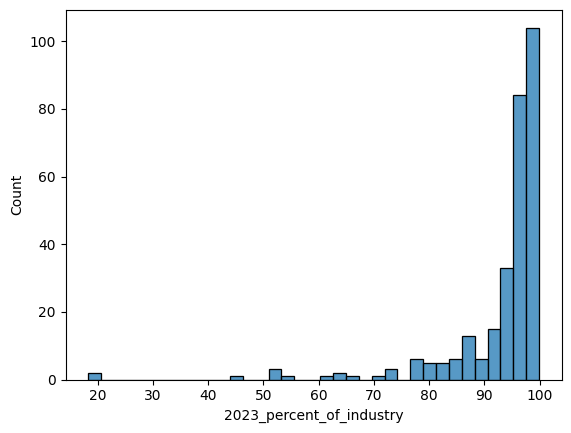

In [44]:
sns.histplot(df_industry_occupations.groupby("industry_code")["2023_percent_of_industry"].sum().sort_values())

In [49]:
df_industry_occupations["occupation_level"].value_counts(normalize=True)

occupation_level
detailed_occupation    0.983844
broad_group            0.016156
Name: proportion, dtype: float64

,occupation_type,industry_type,industry_code,sector_code,subsector_code,industry_group_code,naics_industry_code,industry_title,occupation_code,2023_percent_of_industry,2033_percent_of_industry,occupation_title,occupation_level,occupation_code_prefix
26349,Line item,Line item,61150L,610000,611000,611500,611500,Technical and trade schools; local,253031,2.6,2.6,"Substitute Teachers, Short-Term",detailed_occupation,25
29256,Line item,Line item,623100,620000,623000,623100,623100,Nursing care facilities (skilled nursing facil...,433031,0.4,0.3,"Bookkeeping, Accounting, and Auditing Clerks",detailed_occupation,43
16465,Line item,Line item,488900,480000,488000,488900,488900,Other support activities for transportation,436014,0.7,0.7,"Secretaries and Administrative Assistants, Exc...",detailed_occupation,43
30184,Line item,Line item,624300,620000,624000,624300,624300,Vocational rehabilitation services,273091,0.0,0.0,Interpreters and Translators,detailed_occupation,27
31207,Line item,Line item,713200,710000,713000,713200,713200,Gambling industries (except casino hotels),112021,0.4,0.4,Marketing Managers,detailed_occupation,11


,industry_title,occupation_title,2023_percent_of_industry
26343,Technical and trade schools; local,"Career/Technical Education Teachers, Postsecon...",28.0
26360,Technical and trade schools; local,"Secretaries and Administrative Assistants, Exc...",5.4
26346,Technical and trade schools; local,"Career/Technical Education Teachers, Secondary...",5.2
26354,Technical and trade schools; local,"Janitors and Cleaners, Except Maids and Housek...",3.8
26347,Technical and trade schools; local,"Adult Basic Education, Adult Secondary Educati...",3.7
26339,Technical and trade schools; local,"Educational, Guidance, and Career Counselors a...",3.4
26350,Technical and trade schools; local,Instructional Coordinators,3.2
26335,Technical and trade schools; local,"Education Administrators, Postsecondary",2.9
26349,Technical and trade schools; local,"Substitute Teachers, Short-Term",2.6
26341,Technical and trade schools; local,"Health Specialties Teachers, Postsecondary",2.6


# Playground


In [2]:
DATA_FOLDER = "../data/processed"
lf = pl.scan_parquet(f"{DATA_FOLDER}/index_data.parquet")

In [3]:
lf.collect_schema().names()

['unique_id',
 'sex',
 'race',
 'age',
 'highest_educational_level',
 'low_income_status',
 'employment_status',
 'occupational_code_pre',
 'industry_code_q1_pre',
 'industry_code_q2_pre',
 'industry_code_q3_pre',
 'wages_3q_pre',
 'wages_2q_pre',
 'wages_1q_pre',
 'occupational_code_post',
 'industry_code_q1_post',
 'industry_code_q2_post',
 'industry_code_q3_post',
 'industry_code_q4_post',
 'wages_1q_post',
 'wages_2q_post',
 'wages_3q_post',
 'wages_4q_post',
 'workforce_board_code_1',
 'workforce_board_code_2',
 'workforce_board_code_3',
 'state',
 'is_adult',
 'is_dislocated_worker',
 'is_youth',
 'is_wagner_peyser',
 'is_reportable_individual',
 'received_training',
 'entry_date',
 'exit_date',
 'entry_year',
 'entry_quarter',
 'exit_year',
 'exit_quarter',
 'industry_code_pre',
 'industry_code_post',
 'funding_stream',
 'subsector_code_pre',
 'subsector_code_post',
 '',
 'occupation_title_pre',
 'r_cog_pre',
 'r_man_pre',
 'offshor_pre',
 '_right',
 'occupation_title_post',
 'r

In [4]:
n_rows = lf.select(pl.len()).collect().item()
print("Number of rows: ", n_rows)

Number of rows:  12726789


In [5]:
df = lf.collect()

In [6]:
df_sample = df.sample(fraction=0.01, with_replacement=False)
n_rows_sample = df_sample.select(pl.len()).item()
print("Number of rows in sample: ", n_rows_sample)

Number of rows in sample:  127267


In [7]:
df_sample = df_sample.to_pandas()

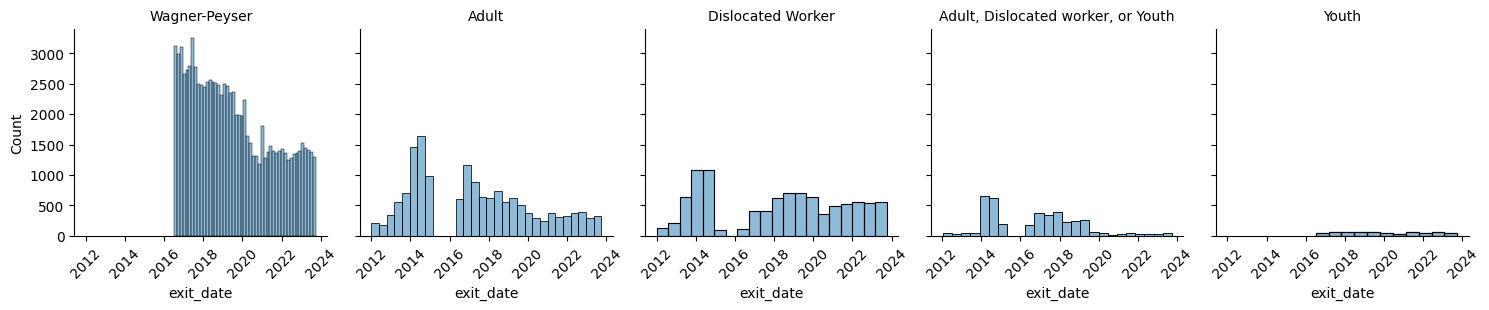

In [8]:
g = sns.FacetGrid(df_sample, col="funding_stream", despine=True)

g.map_dataframe(sns.histplot, x="exit_date", hue="funding_stream")

g.set_titles(col_template="{col_name}")

for ax in g.axes.flatten():
    ax.tick_params(axis='x', rotation=45)

g.figure.show()

In [35]:
import matplotlib.pyplot as plt

In [45]:
df_sample.columns

Index(['unique_id', 'sex', 'race', 'age', 'highest_educational_level',
       'low_income_status', 'employment_status', 'occupational_code_pre',
       'industry_code_q1_pre', 'industry_code_q2_pre', 'industry_code_q3_pre',
       'wages_3q_pre', 'wages_2q_pre', 'wages_1q_pre',
       'occupational_code_post', 'industry_code_q1_post',
       'industry_code_q2_post', 'industry_code_q3_post',
       'industry_code_q4_post', 'wages_1q_post', 'wages_2q_post',
       'wages_3q_post', 'wages_4q_post', 'workforce_board_code_1',
       'workforce_board_code_2', 'workforce_board_code_3', 'state', 'is_adult',
       'is_dislocated_worker', 'is_youth', 'is_wagner_peyser',
       'is_reportable_individual', 'received_training', 'entry_date',
       'exit_date', 'entry_year', 'entry_quarter', 'exit_year', 'exit_quarter',
       'industry_code_pre', 'industry_code_post', 'funding_stream',
       'subsector_code_pre', 'subsector_code_post', '', 'occupation_title_pre',
       'r_cog_pre', 'r_man_pre',

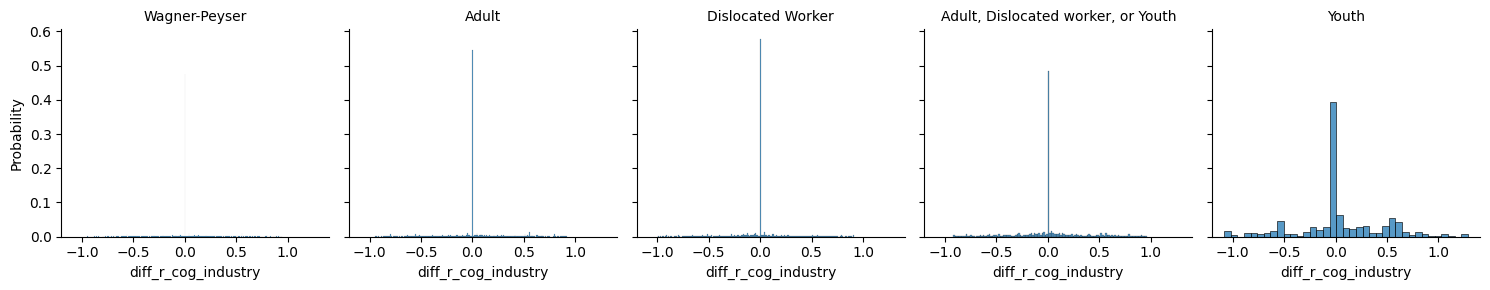

In [73]:
metric = "diff_r_cog_industry"

q_low = df_sample.groupby("funding_stream")[metric].transform(lambda x: x.quantile(0.01))
q_high = df_sample.groupby("funding_stream")[metric].transform(lambda x: x.quantile(0.99))

df_filtered = df_sample[(df_sample[metric] >= q_low) & (df_sample[metric] <= q_high)]

g = sns.FacetGrid(df_filtered, col="funding_stream", despine=True)

g.map_dataframe(sns.histplot, x=metric, stat="probability")

# for ax in g.axes.flatten():
#     ax.set_xlim(-100000, 100000)

g.set_titles(col_template="{col_name}")

g.figure.show()